In [14]:
import pandas as pd
import numpy as np
import os
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib as mpl

In [15]:
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amsfonts,geometry}'
mpl.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams.update({
    'font.family':'serif',
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "font.size": 30,
    "figure.figsize":(13,8),
    "lines.markersize": 20
})
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.rcParams['axes.xmargin'] = 0
plt.rcParams['axes.ymargin'] = 0

In [58]:
model_families=['llama','qwen','mistral']
model_labels=dict()
model_labels['llama']={'meta-llama/Llama-3.1-8B-Instruct':'8B',
              'meta-llama/Llama-3.1-8q-Instruct':'bnb-8bit',
                'meta-llama/Llama-3.1-4q-Instruct':'bnb-4bit',
              'hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4':'AWQ-INT4',
              'meta-llama/Llama-3.2-3B-Instruct':'3B',
              'meta-llama/Llama-3.2-1B-Instruct':'1B'
}

model_labels['qwen']={
        "Qwen/Qwen3-8B":'3-8B',
        "Qwen/Qwen2.5-7B-Instruct-q8":'2.5-7B-bnb-8bit',
        "Qwen/Qwen2.5-7B-Instruct":'2.5-7B',
        "Qwen/Qwen2.5-7B-Instruct-q4":'2.5-7B-bnb-4bit',
        "Qwen/Qwen2.5-7B-Instruct-AWQ":'2.5-7B-AWQ-INT4',
        "Qwen/Qwen2.5-3B-Instruct":'2.5-3B',
        "Qwen/Qwen2.5-1.5B-Instruct":'2.5-1.5B',
        "alibaba-pai/DistilQwen2.5-3B-Instruct":'2.5-3B-distil'}
model_labels['mistral']={"mistralai/Mistral-7B-Instruct-v0.3":'v0.3',
                         "mistralai/Mistral-7B-Instruct-v0.3-q8":'v0.3-bnb-8bit',
                         "mistralai/Mistral-7B-Instruct-v0.3-q4":'v0.3-bnb-4bit',
                         "mistralai/Mistral-7B-Instruct-v0.2":'v0.2',
                        "mistralai/Mistral-7B-Instruct-v0.1":'v0.1'}

models_full=dict()
models_full['llama']=['meta-llama/Llama-3.1-8B-Instruct',
             'meta-llama/Llama-3.1-8q-Instruct',
             'meta-llama/Llama-3.1-4q-Instruct',
             'hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4',
             'meta-llama/Llama-3.2-3B-Instruct',
             'meta-llama/Llama-3.2-1B-Instruct']
models_full['qwen']=[
        "Qwen/Qwen3-8B",
        "Qwen/Qwen2.5-7B-Instruct",
        "Qwen/Qwen2.5-7B-Instruct-q8",
        "Qwen/Qwen2.5-7B-Instruct-q4",
        "Qwen/Qwen2.5-7B-Instruct-AWQ",
        "Qwen/Qwen2.5-3B-Instruct",
        "Qwen/Qwen2.5-1.5B-Instruct",
        "alibaba-pai/DistilQwen2.5-3B-Instruct"]
models_full['mistral']=["mistralai/Mistral-7B-Instruct-v0.3",
        "mistralai/Mistral-7B-Instruct-v0.3-q8",
        "mistralai/Mistral-7B-Instruct-v0.3-q4",
        "mistralai/Mistral-7B-Instruct-v0.2",
        "mistralai/Mistral-7B-Instruct-v0.1",
        ]

### Read pairwise comparison data

In [46]:
output_dirs={m:f'../outputs/LMSYS/{m}/' for m in model_families}
clean_different_set=dict()
clean_shared_set=dict()

for m in model_families:
    # for queries that were asked in reverse model order, switch winner/models/seeds to match original order
    def swap_order(row):
        if models_full[m].index(row['model_a']) > models_full[m].index(row['model_b']):
            row['winner'] = 'A' if row['winner'] == 'B' else 'B' if row['winner'] == 'A' else row['winner']
            row['seed_a'], row['seed_b'] = row['seed_b'], row['seed_a']
            row['model_a'], row['model_b'] = row['model_b'], row['model_a']
        return row

    clean_different=pd.read_csv(f'{output_dirs[m]}independent_comparisons.csv',index_col=0)
    clean_shared=pd.read_csv(f'{output_dirs[m]}coupled_comparisons.csv',index_col=0)


    clean_different_set[m]=clean_different.apply(swap_order,axis=1)
    clean_shared_set[m]=clean_shared.apply(swap_order,axis=1)

### Compute win-rates and rank-sets

Code to compute rank-sets based on [Prediction-Powered Ranking of Large Language Models](https://github.com/Networks-Learning/prediction-powered-ranking).

In [47]:
def summarize_dataset(models, dataset):
    n = len(dataset['winner'])
    
    winner1_llm = np.zeros(shape=(n,1))
    winner2_llm = np.zeros(shape=(n,1))
    model_a_matrix = np.zeros(shape=(len(models),n))
    model_b_matrix = np.zeros(shape=(len(models),n))
    
    for i in range(n):        
        if dataset['winner'][i] == 'A':
            winner1_llm[i] = 1
        elif dataset['winner'][i] == 'B':
            winner2_llm[i] = 1
        
        model_a_matrix[models.index(dataset['model_a'][i])][i] = 1
        model_b_matrix[models.index(dataset['model_b'][i])][i] = 1
    
    summarized = {'winner1_predicted':winner1_llm,
                  'winner2_predicted':winner2_llm,
                  'model_a_matrix': model_a_matrix,
                  'model_b_matrix': model_b_matrix}
        
    return summarized

def sample_avg(k, Dn):
    n = np.shape(Dn['model_a_matrix'])[1]
    M1, M2 = Dn['model_a_matrix'], Dn['model_b_matrix']
    w1, w2 = Dn['winner1_predicted'], Dn['winner2_predicted']
    
    a = np.matmul(np.ones((k,1)), np.transpose(np.matmul(
        M1+M2,np.ones((n,1))))) *np.identity(k)
    for i in range(k):
        a[i][i] = 1/a[i][i]
    a = np.matmul(a,np.matmul(M1,w1) + np.matmul(M2,w2))
    
    A = np.matmul(np.ones((k,1)), np.transpose(
        w1 - np.matmul(np.transpose(M1) ,a)))*M1
    A += np.matmul(np.ones((k,1)), 
                   np.transpose(w2 - np.matmul(np.transpose(M2), a)))*M2
    
    Sigma = (np.matmul(A, np.transpose(A)))/(n**2)
    
    return a, Sigma

import scipy.stats as stats

def find_ranksets(k, thetahat, Sigma, alpha=0.05):
    lhat = np.ones((k,1))
    uhat = np.ones((k,1))*k
    
    assert alpha>0 and alpha<1, 'alpha must be between 0 and 1'
    
    for m1 in range(k):
        for m2 in range(k):
            if m1 == m2:
                continue
            d = abs(thetahat[m1] - thetahat[m2])/np.sqrt(2) - \
            np.sqrt((Sigma[m1][m1] + Sigma[m2][m2] - 2*Sigma[m1][m2])*\
                    (stats.chi2.ppf(1-alpha,k)/(2)))
            if d > 0 and thetahat[m1] < thetahat[m2]:
                lhat[m1] += 1
            elif d > 0 and thetahat[m1] > thetahat[m2]:
                uhat[m1] -= 1
    
    return [[int(lhat[m][0]), int(uhat[m][0])] for m in range(k)]

### Pairwise win-rates

In [48]:
def compute_pairwise_winrates(df,models):
    winrates=dict()
    ci=dict()
    for m1 in range(len(models)):
        for m2 in range(m1+1,len(models)):
            wins_A=len(df[(df['model_a'] == models[m1]) & (df['model_b'] == models[m2]) & (df['winner'] == 'A')])
            wins_B=len(df[(df['model_a'] == models[m1]) & (df['model_b'] == models[m2]) & (df['winner'] == 'B')])
            winrates[(models[m1],models[m2])]=wins_A/len(df[(df['model_a'] == models[m1]) & (df['model_b'] == models[m2])])
            winrates[(models[m2],models[m1])]=wins_B/len(df[(df['model_a'] == models[m1]) & (df['model_b'] == models[m2])])
        
            ci[(models[m1],models[m2])]=1.96*np.sqrt(winrates[(models[m1],models[m2])]*(1-winrates[(models[m1],models[m2])])/len(df[(df['model_a'] == models[m1]) & (df['model_b'] == models[m2])]))
            ci[(models[m2],models[m1])]=1.96*np.sqrt(winrates[(models[m2],models[m1])]*(1-winrates[(models[m2],models[m1])])/len(df[(df['model_a'] == models[m1]) & (df['model_b'] == models[m2])]))
    return winrates,ci

p_w_s, ci_s, p_w_d, ci_d = dict(), dict(), dict(), dict()

for m in model_families:
    p_w_s[m],ci_s[m]=compute_pairwise_winrates(clean_shared_set[m],models_full[m])
    p_w_d[m],ci_d[m]=compute_pairwise_winrates(clean_different_set[m],models_full[m])

### Ties per pair of models

In [49]:
# Count number of ties per pair of models
def compute_ties(df,models):
    ties=[[0 for _ in range(len(models))] for _ in range(len(models))]
    for m1 in range(len(models)):
        for m2 in range(m1,len(models)):
            if m1==m2:
                ties[m1][m2]=0
            ties[m1][m2]=len(df[(df['model_a'] == models[m1]) & (df['model_b'] == models[m2]) & (df['winner'] == 'Tie')])
            ties[m2][m1]=len(df[(df['model_a'] == models[m1]) & (df['model_b'] == models[m2]) & (df['winner'] == 'Tie')])
    return ties

for m in model_families:
    ties_different=compute_ties(clean_different_set[m],models_full[m])
    ties_shared=compute_ties(clean_shared_set[m],models_full[m])

    # compute relative increase in ties under shared noise compared to different noise
    ties_diff=[[0 for j in range(len(models_full[m]))] for i in range(len(models_full[m]))]
    for i in range(len(models_full[m])):
        for j in range(len(models_full[m])):
            if i==j:
                continue
            ties_diff[i][j]=100*(ties_shared[i][j]-ties_different[i][j])/ties_different[i][j]
    print(m)
    print(ties_diff)

llama
[[0, 23.544411389715258, 8.442694663167105, 8.388520971302428, 1.9928461931527848, 2.3424878836833605], [23.544411389715258, 0, 11.326097215667767, 14.729064039408867, 5.224274406332454, -2.6548672566371683], [8.442694663167105, 11.326097215667767, 0, 5.865657521286661, 3.3157894736842106, -0.14803849000740193], [8.388520971302428, 14.729064039408867, 5.865657521286661, 0, -1.2833675564681726, 6.031746031746032], [1.9928461931527848, 5.224274406332454, 3.3157894736842106, -1.2833675564681726, 0, 7.341269841269841], [2.3424878836833605, -2.6548672566371683, -0.14803849000740193, 6.031746031746032, 7.341269841269841, 0]]
qwen
[[0, -0.5130397605814451, 1.3250517598343685, 1.6351118760757315, 1.4691943127962086, 5.164585698070375, 2.0974289580514207, 0.1720183486238532], [-0.5130397605814451, 0, 15.336134453781513, 5.5391674860701405, 3.255975060616557, 3.080568720379147, -0.3255208333333333, 0.0], [1.3250517598343685, 15.336134453781513, 0, 4.633585277686493, 3.7899860917941584, -0.

## Figures 3a, 15, 26, 34 and Tables 3b, 7, 9

In [50]:
def hypothesis_test_pairwise(dfs,dfd,models,m1,m2):
    count_s=len(dfs[(dfs['model_a']==models[m1]) & (dfs['model_b']==models[m2])])
    count_s+=len(dfs[(dfs['model_a']==models[m2]) & (dfs['model_b']==models[m1])])

    count_d=len(dfd[(dfd['model_a']==models[m1]) & (dfd['model_b']==models[m2])])
    count_d+=len(dfd[(dfd['model_a']==models[m2]) & (dfd['model_b']==models[m1])])

    win_s=len(dfs[(dfs['model_a'] == models[m1]) & (dfs['model_b'] == models[m2]) & (dfs['winner'] == 'A')])
    win_s+=len(dfs[(dfs['model_a'] == models[m2]) & (dfs['model_b'] == models[m1]) & (dfs['winner'] == 'B')])

    win_d=len(dfd[(dfd['model_a'] == models[m1]) & (dfd['model_b'] == models[m2]) & (dfd['winner'] == 'A')])
    win_d+=len(dfd[(dfd['model_a'] == models[m2]) & (dfd['model_b'] == models[m1]) & (dfd['winner'] == 'B')])

    p_s=win_s/count_s
    p_d=win_d/count_d

    p=(win_s+win_d)/(count_s+count_d)
    z=(p_s-p_d)/np.sqrt(p*(1-p)*(1/count_s+1/count_d))

    p_value = scipy.stats.norm.sf(abs(z))*2
    if p_value<0.0001:
        return '****'
    if p_value<0.001:
        return '***'
    if p_value<0.01:
        return '**'
    if p_value<0.05:
        return '*'
    else:
        return 'ns'

# figure 3
def plot_pairwise_winrates_barplot(p_w_s,ci_s,p_w_d,ci_d,models_full,model, family):
    fig, ax = plt.subplots(figsize=(12,6))
    labels=[model_labels[family][m] for m in models_full if m != model]
    winrates_shared={model_labels[family][m]:p_w_s[(model,m)] for m in models_full if m != model}
    ci_shared={model_labels[family][m]:ci_s[(model,m)] for m in models_full if m != model}
    winrates_different={model_labels[family][m]:p_w_d[(model,m)] for m in models_full if m != model}
    ci_different={model_labels[family][m]:ci_d[(model,m)] for m in models_full if m != model}
    x=np.arange(len(labels))
    ax.bar(x-0.15, winrates_shared.values(), width=0.3, label='Coupled', color='teal',alpha=0.8)
    ax.bar(x+0.15, winrates_different.values(), width=0.3, label='Independent', color='palevioletred',alpha=0.8)
    
    ax.errorbar(x-0.15, winrates_shared.values(), yerr=ci_shared.values(), fmt='none', ecolor='black', capsize=5)
    ax.errorbar(x+0.15, winrates_different.values(), yerr=ci_different.values(), fmt='none', ecolor='black', capsize=5)

    for m in range(len(models_full)):
        if models_full[m]==model:
            continue
        annot=hypothesis_test_pairwise(clean_shared_set[family],clean_different_set[family],models_full,models_full.index(model),m)
        if annot!='ns':
            y_star=max(winrates_shared[model_labels[family][models_full[m]]]+ci_shared[model_labels[family][models_full[m]]],winrates_different[model_labels[family][models_full[m]]]+ci_different[model_labels[family][models_full[m]]])
            x_star=m
            if models_full.index(model) <m:
                x_star-=1
            ax.plot([x_star-0.2, x_star-0.2, x_star+0.2, x_star+0.2], [y_star+0.02, y_star+0.04, y_star+0.04, y_star+0.02], lw=1.5, c='k')
            ax.text(x_star-0.05*len(annot),y_star+0.03,annot,fontsize=30)

    ax.set_xticks(x)
    ax.set_xlim(-0.5,len(labels)-0.5)
    ax.set_xticklabels(labels, rotation=35,ha='right',rotation_mode='anchor')
    ax.set_ylabel(f'Win-rate')
    ax.spines[['top','right']].set_visible(False)
    ax.legend(frameon=False,ncol=2,loc='upper center',bbox_to_anchor=(0.5,1.05))
    folder_path = f'../figures/LMSYS/{family}'
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    fig.savefig(f'../figures/LMSYS/{family}/pairwise_winrates_{model_labels[family][model]}.pdf',bbox_inches='tight')
    plt.show()

# figure 6
def plot_pairwise_winrates_all(p_w_s,ci_s,p_w_d,ci_d,models, family):
    if family=='llama':
        fig,ax=plt.subplots(3,2,figsize=(15,15),sharey=True)
        fig.subplots_adjust(left=0.125, bottom=0.1, right=0.9, top=0.9, wspace=0.2, hspace=1)
    elif family=='qwen':
        fig,ax=plt.subplots(4,2,figsize=(15,18),sharey=True)
        fig.subplots_adjust(left=0.125, bottom=0.1, right=0.9, top=0.9, wspace=0.2, hspace=1.7)
    elif family=='mistral':
        fig,ax=plt.subplots(3,2,figsize=(13,13),sharey=True)
        fig.subplots_adjust(left=0.125, bottom=0.1, right=0.9, top=0.9, wspace=0.2, hspace=1)
    # fig.tight_layout()
    ax=ax.flatten()
    for i in range(len(models)):
        labels=[model_labels[family][m] for m in models if m != models[i]]
        x=np.arange(len(labels))

        winrates_shared={model_labels[family][m]:p_w_s[(models[i],m)] for m in models if m != models[i]}
        ci_shared={model_labels[family][m]:ci_s[(models[i],m)] for m in models if m != models[i]}
        winrates_different={model_labels[family][m]:p_w_d[(models[i],m)] for m in models if m != models[i]}
        ci_different={model_labels[family][m]:ci_d[(models[i],m)] for m in models if m != models[i]}

        ax[i].bar(x-0.15, winrates_shared.values(), width=0.3, label='Coupled', color='teal',alpha=0.8)
        ax[i].bar(x+0.15, winrates_different.values(), width=0.3, label='Independent', color='palevioletred',alpha=0.8)
        
        ax[i].errorbar(x-0.15, winrates_shared.values(), yerr=ci_shared.values(), fmt='none', ecolor='black', capsize=5)
        ax[i].errorbar(x+0.15, winrates_different.values(), yerr=ci_different.values(), fmt='none', ecolor='black', capsize=5)

        for m in range(len(models_full[family])):
                if models_full[family][m]==models[i]:
                    continue
                annot=hypothesis_test_pairwise(clean_shared_set[family],clean_different_set[family],models_full[family],models_full[family].index(models[i]),m)
                if annot!='ns':
                    y_star=max(winrates_shared[model_labels[family][models_full[family][m]]]+ci_shared[model_labels[family][models_full[family][m]]],winrates_different[model_labels[family][models_full[family][m]]]+ci_different[model_labels[family][models_full[family][m]]])
                    x_star=m
                    if models_full[family].index(models[i]) <m:
                        x_star-=1
                    x_offset=0.1 if family=='qwen' else 0.068
                    ax[i].plot([x_star-0.2, x_star-0.2, x_star+0.2, x_star+0.2], [y_star+0.02, y_star+0.04, y_star+0.04, y_star+0.02], lw=1.5, c='k')
                    ax[i].text(x_star-x_offset*len(annot),y_star+0.03,annot,fontsize=25) # -0.08

        if i%2==0:
            ax[i].set_ylabel('Win-rate')
            ax[i].set_ylim(0,0.76)
            ax[i].set_yticks([0,0.25,0.5,0.75])
        ax[i].set_title(model_labels[family][models[i]])
        
        ax[i].set_xlim(-0.5,len(labels)-0.5)
        ax[i].set_xticks(x)
        ax[i].set_xticklabels(labels, rotation=35,ha='right',rotation_mode='anchor')
        ax[i].spines[['top','right']].set_visible(False)
    # ax[4].legend(ncol=2,bbox_to_anchor=(1.75,-0.5),frameon=False)
    ax[-2].legend(ncol=2,bbox_to_anchor=(1.75,-1.5 if family=='qwen' else -0.7),frameon=False)
    if family=='mistral':
         ax[-1].axis('off')
    folder_path = f'../figures/LMSYS/{family}'
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    fig.savefig(f'../figures/LMSYS/{family}/pairwise_winrates.pdf',bbox_inches='tight')

    plt.show()


In [51]:
# compute pairwise win-rates and confidence intervals
p_w_s,ci_s, p_w_d, ci_d = dict(), dict(), dict(), dict()

for m in model_families:
    p_w_s[m],ci_s[m]=compute_pairwise_winrates(clean_shared_set[m],models_full[m])
    p_w_d[m],ci_d[m]=compute_pairwise_winrates(clean_different_set[m],models_full[m])

Figure 3a

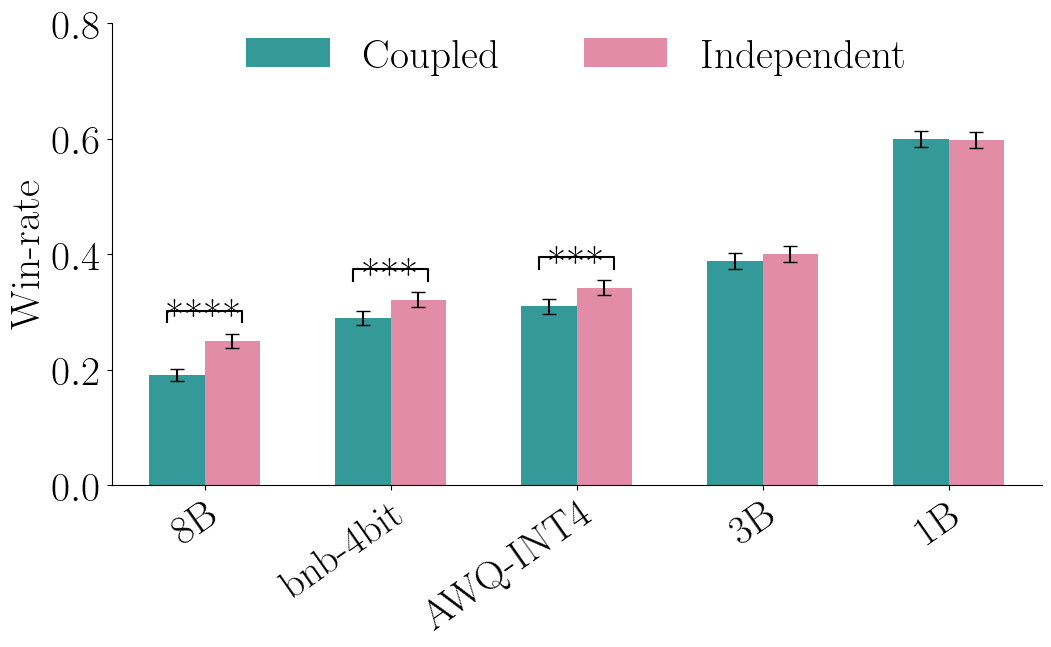

In [52]:
plot_pairwise_winrates_barplot(p_w_s['llama'],ci_s['llama'],p_w_d['llama'],ci_d['llama'],models_full['llama'],models_full['llama'][1],family='llama')

Figures 15, 26 and 35

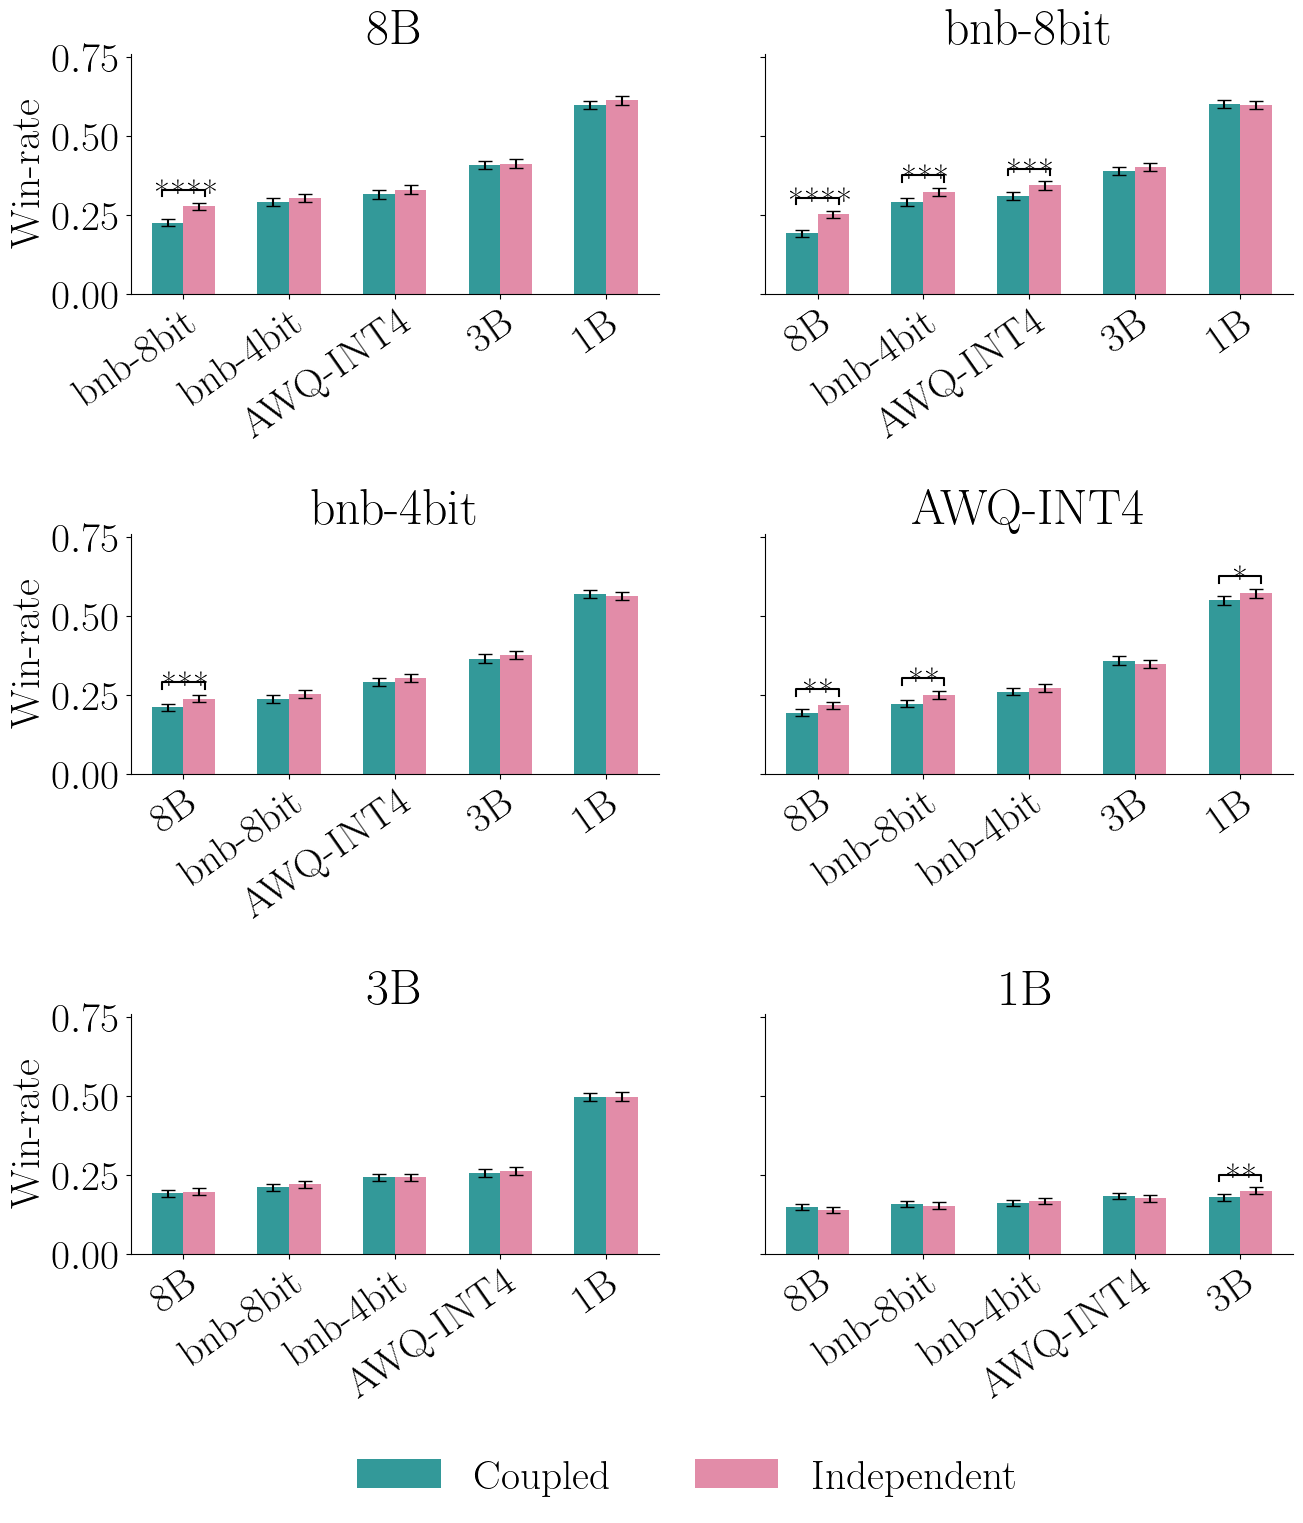

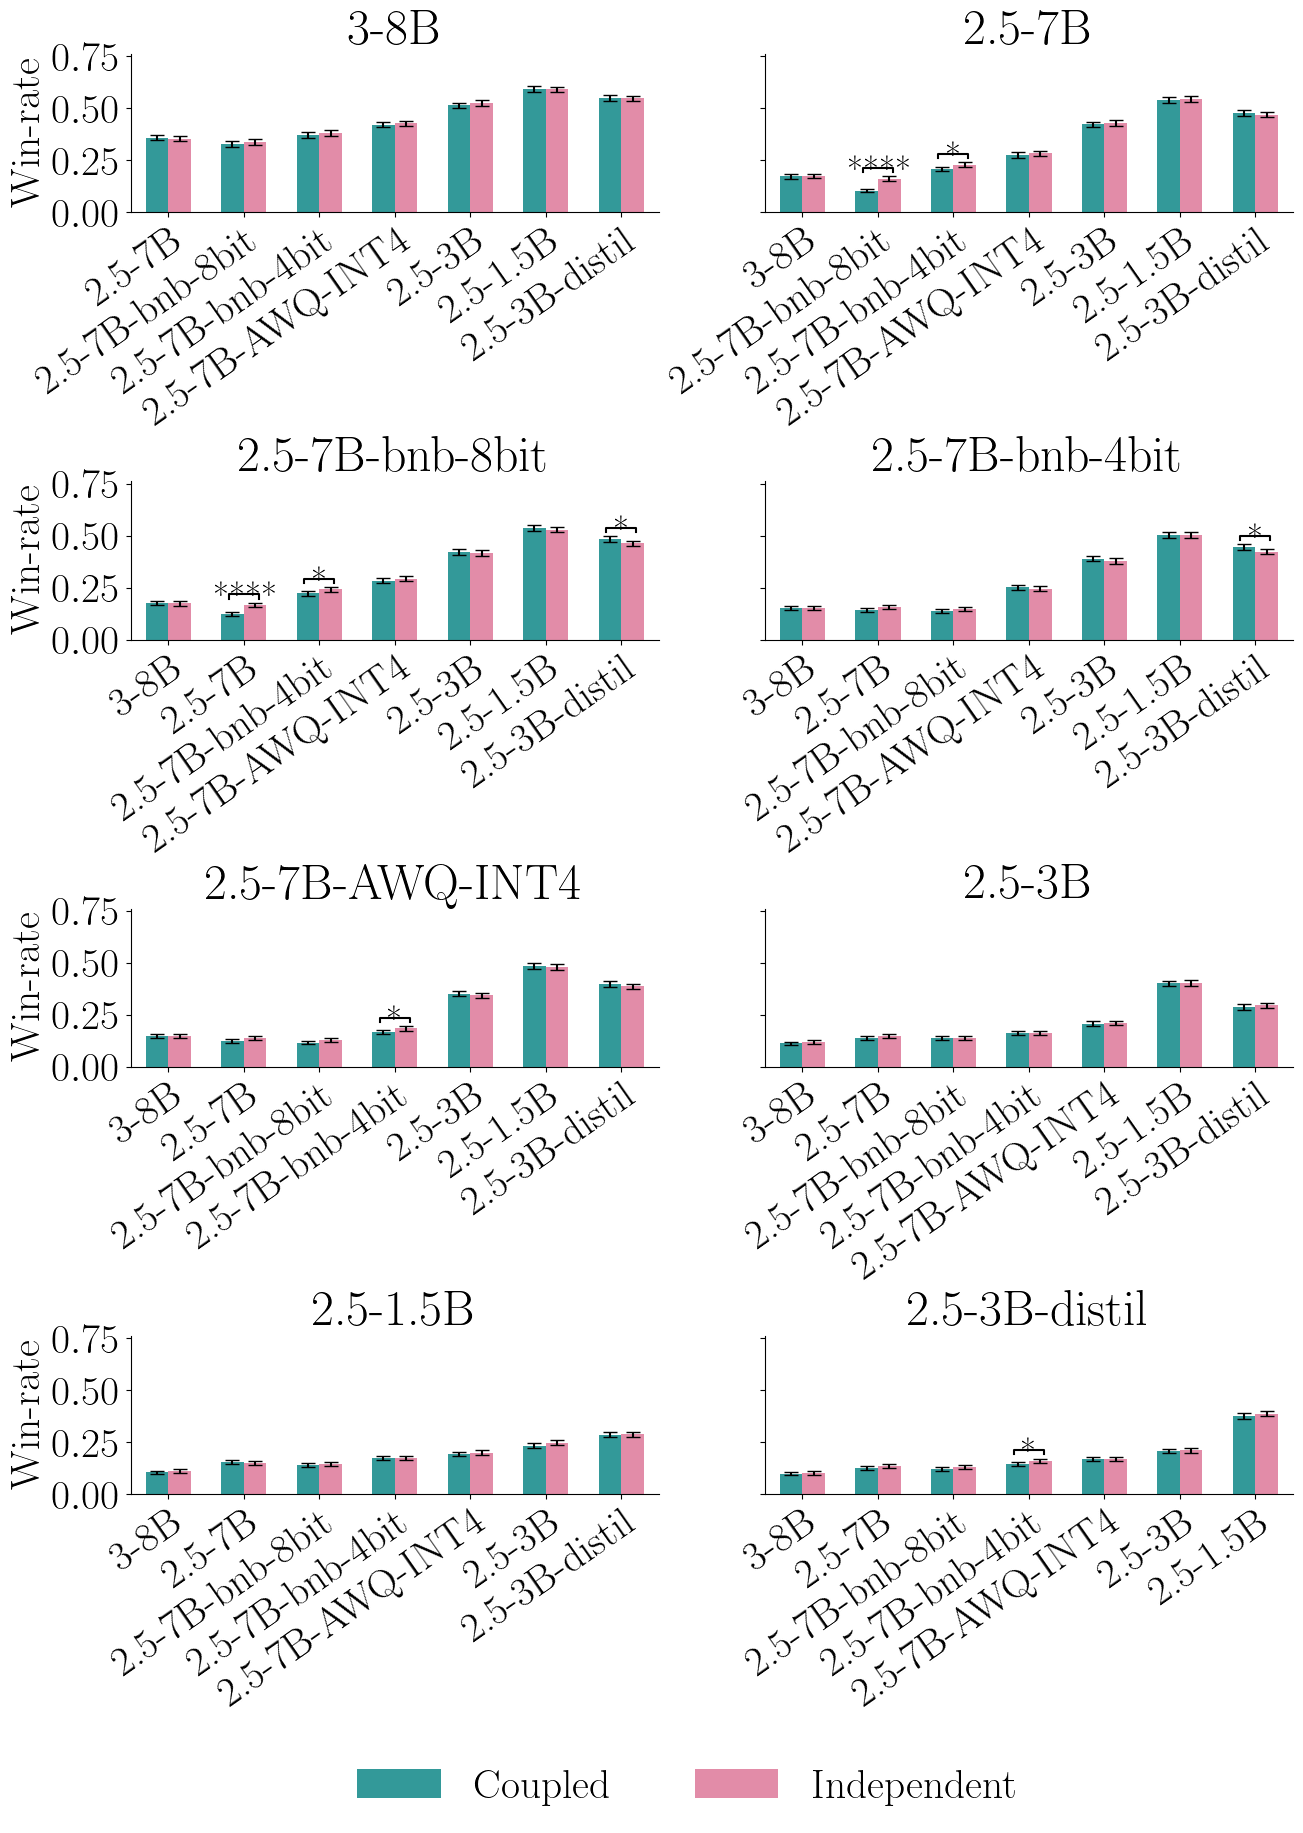

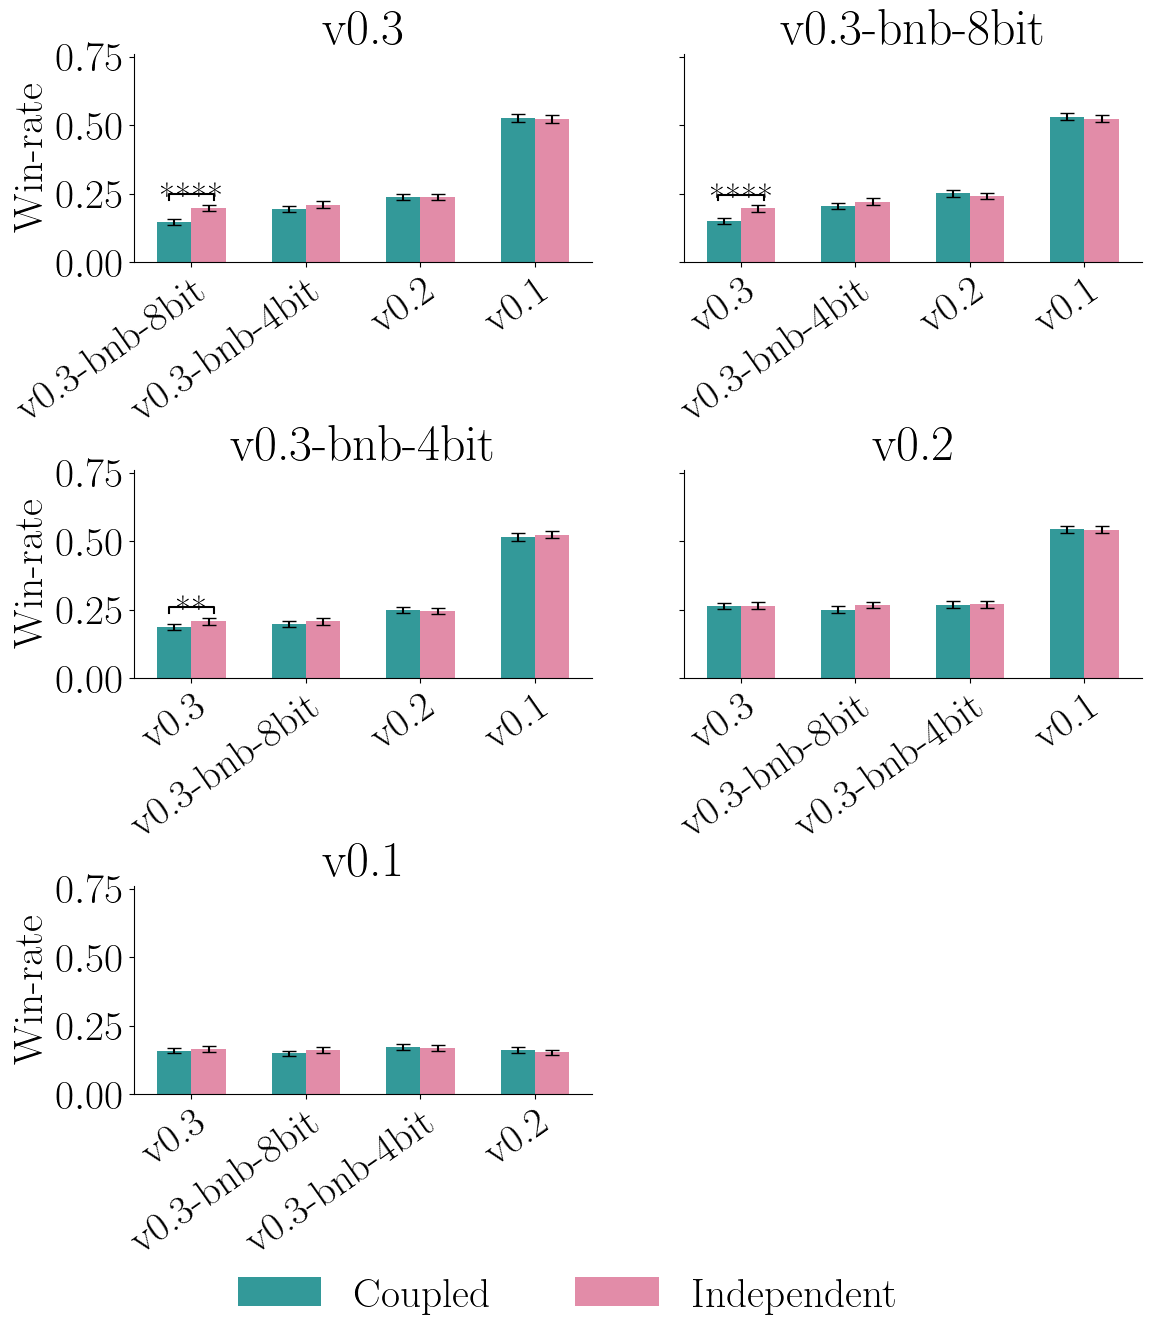

In [59]:
for family in model_families:
    plot_pairwise_winrates_all(p_w_s[family],ci_s[family],p_w_d[family],ci_d[family],models_full[family],family=family)

Tables 3b, 7, 9

In [54]:
model_labels['llama']={'meta-llama/Llama-3.1-8B-Instruct':'8B',
              'meta-llama/Llama-3.1-8q-Instruct':'bnb-8bit',
                'meta-llama/Llama-3.1-4q-Instruct':'bnb-4bit',
              'hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4':'AWQ-INT4',
              'meta-llama/Llama-3.2-3B-Instruct':'3B',
              'meta-llama/Llama-3.2-1B-Instruct':'1B'
}

model_labels['qwen']={
        "Qwen/Qwen3-8B":'3-8B',
        "Qwen/Qwen2.5-7B-Instruct-q8":'2.5-7B-bnb-8bit',
        "Qwen/Qwen2.5-7B-Instruct":'2.5-7B',
        "Qwen/Qwen2.5-7B-Instruct-q4":'2.5-7B-bnb-4bit',
        "Qwen/Qwen2.5-7B-Instruct-AWQ":'2.5-7B-AWQ-INT4',
        "Qwen/Qwen2.5-3B-Instruct":'2.5-3B',
        "Qwen/Qwen2.5-1.5B-Instruct":'2.5-1.5B',
        "alibaba-pai/DistilQwen2.5-3B-Instruct":'2.5-3B-distil'}
model_labels['mistral']={"mistralai/Mistral-7B-Instruct-v0.2":'v0.2',
                         "mistralai/Mistral-7B-Instruct-v0.3-q4":'v0.3-bnb-4bit',
                         "mistralai/Mistral-7B-Instruct-v0.3-q8":'v0.3-bnb-8bit',
                         "mistralai/Mistral-7B-Instruct-v0.3":'v0.3',
                        "mistralai/Mistral-7B-Instruct-v0.1":'v0.1'}

models_full['llama']=['meta-llama/Llama-3.1-8B-Instruct',
             'meta-llama/Llama-3.1-8q-Instruct',
             'meta-llama/Llama-3.1-4q-Instruct',
             'hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4',
             'meta-llama/Llama-3.2-3B-Instruct',
             'meta-llama/Llama-3.2-1B-Instruct']
models_full['qwen']=[
        "Qwen/Qwen3-8B",
        "Qwen/Qwen2.5-7B-Instruct",
        "Qwen/Qwen2.5-7B-Instruct-q8",
        "Qwen/Qwen2.5-7B-Instruct-q4",
        "Qwen/Qwen2.5-7B-Instruct-AWQ",
        "Qwen/Qwen2.5-3B-Instruct",
        "Qwen/Qwen2.5-1.5B-Instruct",
        "alibaba-pai/DistilQwen2.5-3B-Instruct"]
models_full['mistral']=["mistralai/Mistral-7B-Instruct-v0.2",
        "mistralai/Mistral-7B-Instruct-v0.3-q4",
        "mistralai/Mistral-7B-Instruct-v0.3-q8",
        "mistralai/Mistral-7B-Instruct-v0.3",
        "mistralai/Mistral-7B-Instruct-v0.1",
        ]

In [55]:
# compute win-rates and rank-sets under coupled noise
family = 'llama'

thetahat_shared,Sigma_shared=sample_avg(len(models_full[family]),summarize_dataset(models_full[family],clean_shared_set[family].reset_index(drop=True)))
baseline_shared=(find_ranksets(len(models_full[family]), thetahat_shared, Sigma_shared))

# compute win-rates and rank-sets under independent noise
thetahat_different,Sigma_different=sample_avg(len(models_full[family]),summarize_dataset(models_full[family],clean_different_set[family].reset_index(drop=True)))
baseline_different=(find_ranksets(len(models_full[family]), thetahat_different, Sigma_different))

# prepare data for table
winrates_shared={models_full[family][m]:thetahat_shared[m][0] for m in range(len(models_full[family]))}
winrates_different={models_full[family][m]:thetahat_different[m][0] for m in range(len(models_full[family]))}
cid={models_full[family][m]:1.96*np.sqrt(Sigma_different[m][m]) for m in range(len(models_full[family]))}
cis={models_full[family][m]:1.96*np.sqrt(Sigma_different[m][m]) for m in range(len(models_full[family]))}

df=pd.DataFrame()
df['LLM']=model_labels[family].values()
df['Rank (coupled)']=np.arange(1,len(models_full[family])+1)
df['Avg. win-rate (coupled)']=thetahat_shared
df['95% CI (coupled)']=[round(1.96*np.sqrt(Sigma_shared[i][i]),4) for i in range(len(models_full[family]))]
df['Rank (independent)']=[1,1,3,4,5,6]
df['Avg win-rate (independent)']=thetahat_different
df['95% CI (independent)']=[round(1.96*np.sqrt(Sigma_different[i][i]),4) for i in range(len(models_full[family]))]
df

,LLM,Rank (coupled),Avg. win-rate (coupled),95% CI (coupled),Rank (independent),Avg win-rate (independent),95% CI (independent)
0,8B,1,0.366959,0.0020,1,0.386281,0.0020
1,bnb-8bit,2,0.356241,0.0020,1,0.382527,0.0020
2,bnb-4bit,3,0.333896,0.0020,3,0.346346,0.0020
3,AWQ-INT4,4,0.316392,0.0019,4,0.330975,0.0019
4,3B,5,0.278687,0.0019,5,0.282831,0.0019
5,1B,6,0.164999,0.0015,6,0.166432,0.0015


In [56]:
# compute win-rates and rank-sets under coupled noise
family = 'qwen'

thetahat_shared,Sigma_shared=sample_avg(len(models_full[family]),summarize_dataset(models_full[family],clean_shared_set[family].reset_index(drop=True)))
baseline_shared=(find_ranksets(len(models_full[family]), thetahat_shared, Sigma_shared))

# compute win-rates and rank-sets under independent noise
thetahat_different,Sigma_different=sample_avg(len(models_full[family]),summarize_dataset(models_full[family],clean_different_set[family].reset_index(drop=True)))
baseline_different=(find_ranksets(len(models_full[family]), thetahat_different, Sigma_different))

# prepare data for table
winrates_shared={models_full[family][m]:thetahat_shared[m][0] for m in range(len(models_full[family]))}
winrates_different={models_full[family][m]:thetahat_different[m][0] for m in range(len(models_full[family]))}
cid={models_full[family][m]:1.96*np.sqrt(Sigma_different[m][m]) for m in range(len(models_full[family]))}
cis={models_full[family][m]:1.96*np.sqrt(Sigma_different[m][m]) for m in range(len(models_full[family]))}

df=pd.DataFrame()
df['LLM']=model_labels[family].values()
df['Rank (coupled)']=np.arange(1,len(models_full[family])+1)
df['Avg. win-rate (coupled)']=thetahat_shared
df['95% CI (coupled)']=[round(1.96*np.sqrt(Sigma_shared[i][i]),4) for i in range(len(models_full[family]))]
df['Rank (independent)']=[1,2,2,4,5,6,7,8]
df['Avg win-rate (independent)']=thetahat_different
df['95% CI (independent)']=[round(1.96*np.sqrt(Sigma_different[i][i]),4) for i in range(len(models_full[family]))]
df

,LLM,Rank (coupled),Avg. win-rate (coupled),95% CI (coupled),Rank (independent),Avg win-rate (independent),95% CI (independent)
0,3-8B,1,0.448560,0.0013,1,0.452350,0.0013
1,2.5-7B-bnb-8bit,2,0.314782,0.0012,2,0.327916,0.0012
2,2.5-7B,3,0.321089,0.0012,2,0.326415,0.0012
3,2.5-7B-bnb-4bit,4,0.289237,0.0012,4,0.286239,0.0012
4,2.5-7B-AWQ-INT4,5,0.256107,0.0011,5,0.259067,0.0012
5,2.5-3B,6,0.207243,0.0011,6,0.212117,0.0011
6,2.5-1.5B,7,0.183363,0.0010,7,0.187477,0.0010
7,2.5-3B-distil,8,0.177966,0.0010,8,0.185015,0.0010


In [57]:
# compute win-rates and rank-sets under coupled noise
family = 'mistral'

thetahat_shared,Sigma_shared=sample_avg(len(models_full[family]),summarize_dataset(models_full[family],clean_shared_set[family].reset_index(drop=True)))
baseline_shared=(find_ranksets(len(models_full[family]), thetahat_shared, Sigma_shared))

# compute win-rates and rank-sets under independent noise
thetahat_different,Sigma_different=sample_avg(len(models_full[family]),summarize_dataset(models_full[family],clean_different_set[family].reset_index(drop=True)))
baseline_different=(find_ranksets(len(models_full[family]), thetahat_different, Sigma_different))

# prepare data for table
winrates_shared={models_full[family][m]:thetahat_shared[m][0] for m in range(len(models_full[family]))}
winrates_different={models_full[family][m]:thetahat_different[m][0] for m in range(len(models_full[family]))}
cid={models_full[family][m]:1.96*np.sqrt(Sigma_different[m][m]) for m in range(len(models_full[family]))}
cis={models_full[family][m]:1.96*np.sqrt(Sigma_different[m][m]) for m in range(len(models_full[family]))}

df=pd.DataFrame()
df['LLM']=model_labels[family].values()
df['Rank (coupled)']=np.arange(1,len(models_full[family])+1)
df['Avg. win-rate (coupled)']=thetahat_shared
df['95% CI (coupled)']=[round(1.96*np.sqrt(Sigma_shared[i][i]),4) for i in range(len(models_full[family]))]
df['Rank (independent)']=[1,2,2,2,5]
df['Avg win-rate (independent)']=thetahat_different
df['95% CI (independent)']=[round(1.96*np.sqrt(Sigma_different[i][i]),4) for i in range(len(models_full[family]))]
df

,LLM,Rank (coupled),Avg. win-rate (coupled),95% CI (coupled),Rank (independent),Avg win-rate (independent),95% CI (independent)
0,v0.2,1,0.330986,0.0026,1,0.335480,0.0026
1,v0.3-bnb-4bit,2,0.286081,0.0025,2,0.295296,0.0025
2,v0.3-bnb-8bit,3,0.284449,0.0025,2,0.295336,0.0025
3,v0.3,4,0.275656,0.0025,2,0.291786,0.0025
4,v0.1,5,0.159841,0.0020,5,0.161722,0.0020
